# High-Fidelity Monte Carlo Neutronics of an Idealized PWR Fuel Pin Cell

**Criticality · Spectral Characterization · Spatial Flux/Power Mapping · Depletion & Burnup**

---

### Project Overview
This notebook presents a complete Monte Carlo analysis of an **idealized unborated infinite-lattice PWR fuel pin cell** using the open-source code **OpenMC**. The model is intentionally simplified to a single reflective pin cell; it is suitable for methodological demonstration and research-oriented computational studies, but it should not be interpreted as a full-core or fully realistic reactor model.

1. **Criticality calculation** with statistical convergence
2. **Energy-resolved neutron flux** (thermal / epithermal / fast) and continuous-energy spectrum
3. **Spatial mapping** of neutron flux and fission power density with physical normalization
4. **Depletion / burnup analysis** tracking $k_{\mathrm{eff}}$, $^{235}$U consumption, $^{239}$Pu production, and $^{135}$Xe poisoning
5. **Visualization** (600 dpi PNG + vector PDF)

The pin-cell model uses 3.2 wt% enriched UO$_2$, Zircaloy cladding, light-water moderator with $S(\alpha,\beta)$ thermal scattering, and reflective lateral boundaries. All nuclear data are taken from ENDF/B-VII.1.


## 0. Environment Setup & OpenMC Installation

OpenMC is compiled from source so that the exact development version is known and reproducible. System libraries required for HDF5 and PNG support are installed first.


In [1]:
# ============================================================
# 0. CLEAN ENVIRONMENT + BUILD OpenMC FROM SOURCE
# ============================================================
import os, sys, subprocess, shutil

print("--- Cleaning previous builds ---")
%cd /kaggle/working
!rm -rf openmc

print("--- Installing system dependencies ---")
!sudo apt-get update -y > /dev/null
!sudo apt-get install -y g++ cmake libhdf5-dev libpng-dev > /dev/null

print("--- Cloning OpenMC (with submodules) ---")
!git clone --recurse-submodules --depth 1 https://github.com/openmc-dev/openmc.git

print("--- Compiling OpenMC (approx 5-7 min) ---")
%cd /kaggle/working/openmc
!mkdir -p build
%cd build
!cmake -DCMAKE_BUILD_TYPE=Release .. > /dev/null
!make -j$(nproc) > /dev/null
!sudo make install > /dev/null

print("--- Installing Python API ---")
%cd /kaggle/working/openmc
!pip install . --quiet
!pip install openmc_data_downloader scipy matplotlib pandas --quiet

%cd /kaggle/working
import openmc
print("=" * 50)
print(f"SUCCESS: OpenMC {openmc.__version__} ready")
print("=" * 50)


--- Cleaning previous builds ---
/kaggle/working
--- Installing system dependencies ---
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
--- Cloning OpenMC (with submodules) ---
Cloning into 'openmc'...
remote: Enumerating objects: 2055, done.
remote: Counting objects: 100% (2055/2055), done.
remote: Compressing objects: 100% (1601/1601), done.
remote: Total 2055 (delta 451), reused 1119 (delta 358), pack-reused 0 (from 0)
Receiving objects: 100% (2055/2055), 7.61 MiB | 20.14 MiB/s, done.
Resolving deltas: 100% (451/451), done.
--- Compiling OpenMC (approx 5-7 min) ---
/kaggle/working/openmc
/kaggle/working/openmc/build
CMake Warning at cmake/Modules/GetVersionFromGit.cmake:46 (message):
  No git tags found.  Version set to 0.0.0.

  Run 'git fetch --tags' to ensure proper versioning.

  For more information, see OpenMC developer documentation.
Cal

## 1. Nuclear Data Library & Depletion Chain

We use the complete ENDF/B-VII.1 HDF5 library (neutrons + thermal scattering) together with the official PWR depletion chain.



In [2]:
# ============================================================
# 1. NUCLEAR DATA
# ============================================================
import os
import openmc

xs_candidates = [
    "/kaggle/working/endfb-vii.1-hdf5/cross_sections.xml",
    "/kaggle/input/datasets/afridijubairuthso/endfb71/endfb-vii.1-hdf5/cross_sections.xml",
]
chain_candidates = [
    "/kaggle/input/datasets/afridijubairuthso/endfb71/chain_endfb71_pwr.xml",
    "/kaggle/working/chain_endfb71_pwr.xml",
]

tar_path = "/kaggle/input/datasets/afridijubairuthso/endfb71/endfb71.tar.xz"
if os.path.exists(tar_path) and not os.path.exists("/kaggle/working/endfb-vii.1-hdf5"):
    print("--- Extracting ENDF/B-VII.1 cross sections ---")
    os.system(f"tar -xf {tar_path} -C /kaggle/working/")

xs_path = next((p for p in xs_candidates if os.path.exists(p)), None)
chain_path = next((p for p in chain_candidates if os.path.exists(p)), None)

if xs_path is None:
    print("Full library not found - downloading minimal ENDF/B-VII.1 set")
    import openmc_data_downloader as odd
    tmp = openmc.Material()
    tmp.add_element("U", 1.0, enrichment=3.2)
    tmp.add_element("O", 2.0)
    tmp.add_element("Zr", 1.0)
    tmp.add_element("H", 2.0)
    odd.download_cross_section_data(
        openmc.Materials([tmp]),
        libraries=["ENDFB-7.1-NNDC"],
        set_OPENMC_CROSS_SECTIONS=True,
    )
    xs_path = os.environ["OPENMC_CROSS_SECTIONS"]
else:
    os.environ["OPENMC_CROSS_SECTIONS"] = xs_path
    openmc.config["cross_sections"] = xs_path

print(f"Cross sections : {xs_path}")
print(f"Depletion chain: {chain_path if chain_path else 'NOT FOUND - depletion will be skipped'}")

CHAIN_FILE = chain_path


--- Extracting ENDF/B-VII.1 cross sections ---
Cross sections : /kaggle/working/endfb-vii.1-hdf5/cross_sections.xml
Depletion chain: /kaggle/input/datasets/afridijubairuthso/endfb71/chain_endfb71_pwr.xml


## 2. Materials & Geometry – Idealized Unborated PWR Pin Cell

| Component | Material | Density | Key nuclear features |
|-----------|----------|---------|----------------------|
| Fuel      | UO$_2$ 3.2 wt% $^{235}$U | 10.3 g cm$^{-3}$ | Depletable, volume set for burnup |
| Cladding  | Zircaloy-4 (natural Zr) | 6.55 g cm$^{-3}$ | Structural |
| Moderator | Light water | 0.7 g cm$^{-3}$ | $S(\alpha,\beta)$ thermal scattering; unborated |

The geometry is an **idealized infinite-lattice pin cell** using a 1.26 cm pitch and reflective lateral boundaries. This is not a full-core or fully realistic PWR model.


In [3]:
# ============================================================
# 2. MATERIALS & GEOMETRY
# ============================================================
import numpy as np
import openmc
import openmc.model

fuel = openmc.Material(name="UO2 Fuel")
fuel.add_element("U", 1.0, enrichment=3.2)
fuel.add_element("O", 2.0)
fuel.set_density("g/cm3", 10.3)
fuel.temperature = 900.0
fuel.volume = np.pi * (0.39 ** 2) * 1.0
fuel.depletable = True

clad = openmc.Material(name="Zircaloy")
clad.add_element("Zr", 1.0)
clad.set_density("g/cm3", 6.55)
clad.temperature = 600.0

water = openmc.Material(name="Light Water")
water.add_element("H", 2.0)
water.add_element("O", 1.0)
water.set_density("g/cm3", 0.7)
water.temperature = 580.0
water.add_s_alpha_beta("c_H_in_H2O")

materials = openmc.Materials([fuel, clad, water])
materials.export_to_xml()

R_FUEL = 0.39
R_CLAD = 0.45
PITCH  = 1.26

fuel_or = openmc.ZCylinder(r=R_FUEL, name="fuel_or")
clad_or = openmc.ZCylinder(r=R_CLAD, name="clad_or")
box = openmc.model.RectangularPrism(width=PITCH, height=PITCH, boundary_type="reflective")

fuel_cell = openmc.Cell(name="fuel",  fill=fuel,  region=-fuel_or)
clad_cell = openmc.Cell(name="clad",  fill=clad,  region=+fuel_or & -clad_or)
mod_cell  = openmc.Cell(name="mod",   fill=water, region=+clad_or & -box)

universe = openmc.Universe(cells=[fuel_cell, clad_cell, mod_cell])
geometry = openmc.Geometry(universe)
geometry.export_to_xml()

print("Materials & geometry exported")
print(f"   Fuel radius   = {R_FUEL} cm")
print(f"   Clad radius   = {R_CLAD} cm")
print(f"   Lattice pitch = {PITCH} cm")


Materials & geometry exported
   Fuel radius   = 0.39 cm
   Clad radius   = 0.45 cm
   Lattice pitch = 1.26 cm


## 3. Tallies – Spatial, Spectral & Power

Five complementary tallies are defined:

* **Spatial flux** on a 100 × 100 Cartesian mesh (track-length estimator)
* **Energy spectrum** with 500 logarithmically spaced bins (1 meV – 20 MeV)
* **Fission energy deposition** via the `kappa-fission` score, subsequently normalized to 175 W total power for the 1 cm axial model
* **Thermal / Fast flux** maps using energy filters (spectral decomposition)

OpenMC eigenvalue tallies are first obtained per source particle. The plotting section converts flux to n cm$^{-2}$ s$^{-1}$ and `kappa-fission` to W cm$^{-3}$ using the specified 175 W power normalization.


In [4]:
# ============================================================
# 3. TALLIES
# ============================================================
mesh = openmc.RegularMesh()
mesh.dimension = [100, 100, 1]
mesh.lower_left  = [-PITCH/2, -PITCH/2, -0.5]
mesh.upper_right = [ PITCH/2,  PITCH/2,  0.5]
mesh_filter = openmc.MeshFilter(mesh)

energy_bins = np.logspace(-3, 7.3, 501)
energy_filter = openmc.EnergyFilter(energy_bins)

thermal_filter = openmc.EnergyFilter([0.0, 0.625])
fast_filter    = openmc.EnergyFilter([1.0e5, 2.0e7])

t_flux = openmc.Tally(name="spatial_flux")
t_flux.filters = [mesh_filter]
t_flux.scores  = ["flux"]
t_flux.estimator = "tracklength"

t_power = openmc.Tally(name="power_dist")
t_power.filters = [mesh_filter]
t_power.scores  = ["kappa-fission"]
t_power.estimator = "tracklength"

t_spectrum = openmc.Tally(name="flux_spectrum")
t_spectrum.filters = [energy_filter]
t_spectrum.scores  = ["flux"]

t_thermal = openmc.Tally(name="thermal_flux")
t_thermal.filters = [mesh_filter, thermal_filter]
t_thermal.scores  = ["flux"]

t_fast = openmc.Tally(name="fast_flux")
t_fast.filters = [mesh_filter, fast_filter]
t_fast.scores  = ["flux"]

tallies = openmc.Tallies([t_flux, t_power, t_spectrum, t_thermal, t_fast])
tallies.export_to_xml()
print("Tallies defined (spatial, spectrum, thermal, fast, power)")


Tallies defined (spatial, spectrum, thermal, fast, power)


## 4. Simulation Settings & Eigenvalue Run

We request 200 batches (40 inactive) with 50 000 particles per batch. This provides a high-statistics fresh-state reference calculation.

Shannon-entropy monitoring is intentionally **not used** in this notebook because the previous setup produced entropy-mesh warnings for source sites outside the selected mesh. Source convergence is assessed from the inactive-batch treatment and the final eigenvalue statistics instead.


In [5]:
# ============================================================
# 4. SETTINGS + EIGENVALUE RUN
# ============================================================
settings = openmc.Settings()
settings.run_mode   = "eigenvalue"
settings.batches    = 200
settings.inactive   = 40
settings.particles  = 50000
settings.temperature = {"default": 600.0, "method": "interpolation"}
settings.source = openmc.IndependentSource(
    space=openmc.stats.Box([-0.3, -0.3, -0.5], [0.3, 0.3, 0.5])
)
settings.export_to_xml()

model = openmc.Model(geometry=geometry, materials=materials,
                     settings=settings, tallies=tallies)

print("--- Starting eigenvalue calculation ---")
print(f"   Batches: {settings.batches} (inactive {settings.inactive})")
print(f"   Particles/batch: {settings.particles}")
statepoint_path = model.run()
print(f"StatePoint written: {statepoint_path}")


--- Starting eigenvalue calculation ---
   Batches: 200 (inactive 40)
   Particles/batch: 50000
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
     

## 5. Plotting Utilities

All figures are saved at **600 dpi** (PNG) and as vector PDF. Physical flux/power units are applied explicitly from the OpenMC per-source-particle tallies.


In [6]:
# ============================================================
# 5. PLOTTING UTILITIES
# ============================================================
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.ndimage import gaussian_filter
import pathlib
import re

OUT = pathlib.Path("/kaggle/working/figures")
OUT.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
})

def save_fig(name):
    # Save current figure as high-resolution PNG + PDF.
    png = OUT / f"{name}.png"
    pdf = OUT / f"{name}.pdf"
    plt.savefig(png, dpi=600, bbox_inches="tight")
    plt.savefig(pdf, bbox_inches="tight")
    print(f"   Saved: {png.name}  |  {pdf.name}")

def load_statepoint(path=None):
    if path is None:
        candidates = list(pathlib.Path("/kaggle/working").glob("statepoint.*.h5"))
        def sp_number(p):
            m = re.search(r"statepoint\.(\d+)\.h5$", p.name)
            return int(m.group(1)) if m else -1
        candidates.sort(key=sp_number)
        path = candidates[-1] if candidates else "statepoint.200.h5"
    return openmc.StatePoint(str(path))


## 6. Criticality Results & Convergence


In [7]:
# ============================================================
# 6. k-eff & CONVERGENCE
# ============================================================
sp = load_statepoint()
k_combined = sp.keff
print(f"Combined k-effective = {k_combined.nominal_value:.5f} +/- {k_combined.std_dev:.5f}")
print("No Shannon-entropy analysis is used; the entropy mesh was removed because the previous setup generated out-of-mesh source-site warnings.")


Combined k-effective = 1.34905 +/- 0.00032
No Shannon-entropy analysis is used; the entropy mesh was removed because the previous setup generated out-of-mesh source-site warnings.


## 7. Spatial Neutron Flux & Fission Power Density

Gaussian smoothing is applied only for visual clarity; quantitative analyses use the raw tally means. The OpenMC track-length flux tally is converted from per-source-particle track length to physical flux using the 175 W normalization derived from the `kappa-fission` tally.


Total kappa-fission energy = 3.657032e+05 eV/source
Derived source rate       = 2.986750e+15 source/s
Integrated normalized power = 175.000000 W
   Saved: 02_flux_map.png  |  02_flux_map.pdf


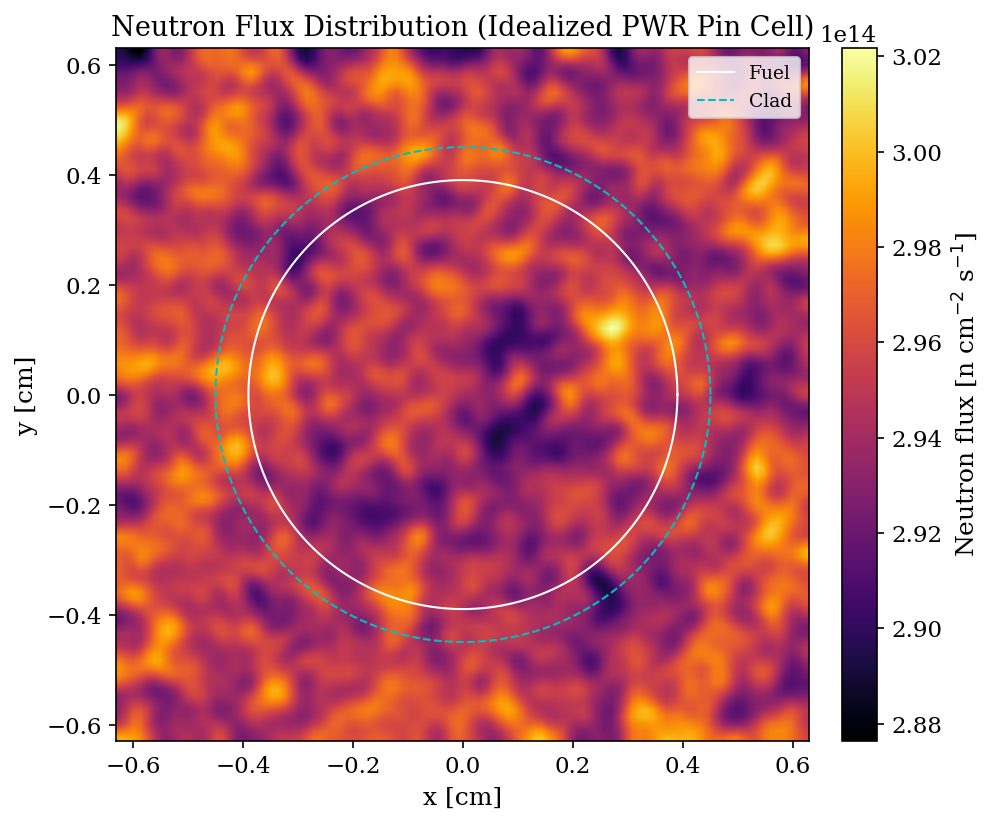

   Saved: 03_flux_rel_error.png  |  03_flux_rel_error.pdf


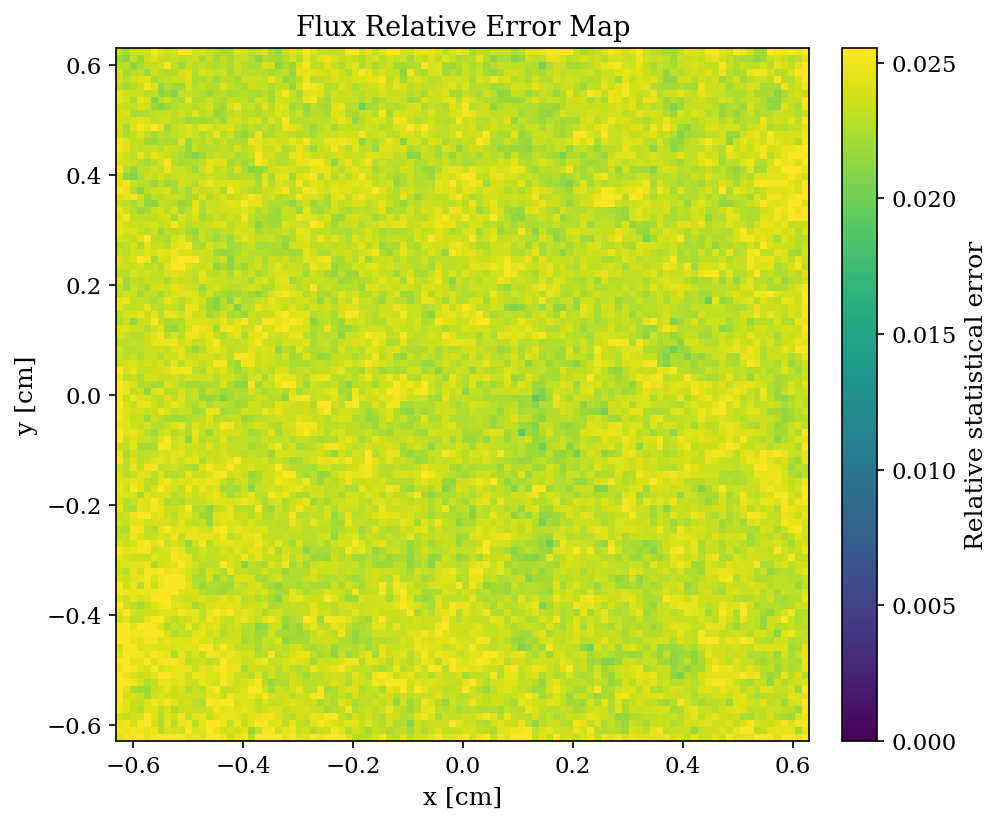

   Saved: 04_power_density.png  |  04_power_density.pdf


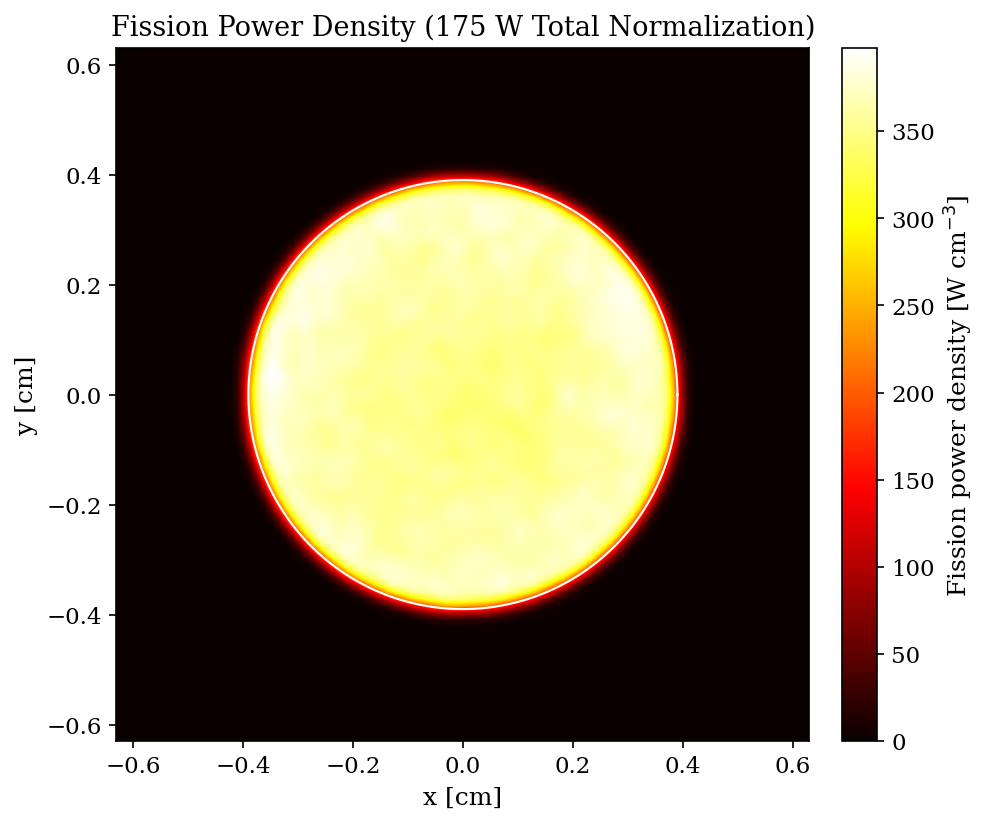

   Saved: 05_radial_flux_profile.png  |  05_radial_flux_profile.pdf


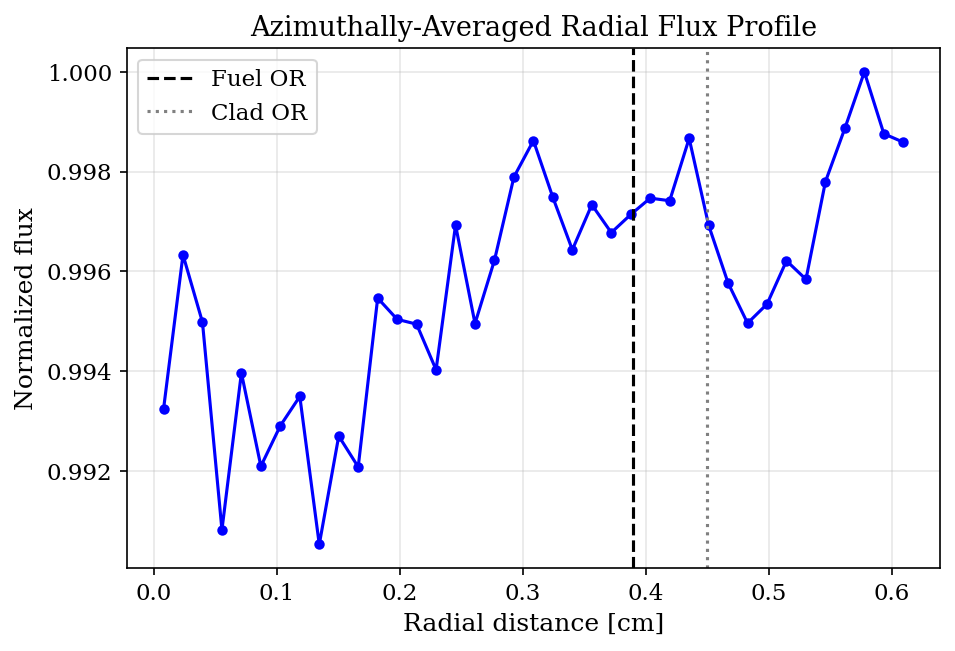

In [8]:
# ============================================================
# 7. SPATIAL FLUX + POWER MAPS
# ============================================================
sp = load_statepoint()

# OpenMC tallies are per source particle. Normalize them to the
# specified 175 W total thermal power for the 1 cm axial model.
EV_TO_J = 1.602176634e-19
AXIAL_HEIGHT = 1.0  # cm represented by the plotting/depletion normalization
PIN_CELL_VOLUME = PITCH**2 * AXIAL_HEIGHT
VOXEL_VOLUME = (PITCH / 100.0)**2 * AXIAL_HEIGHT
TARGET_POWER_W = 175.0

tally_f = sp.get_tally(name="spatial_flux")
flux_raw = tally_f.get_values(scores=["flux"]).reshape(100, 100)
flux_err = tally_f.std_dev.reshape(100, 100)
rel_err = np.divide(flux_err, flux_raw, out=np.zeros_like(flux_raw), where=flux_raw > 0)

tally_p = sp.get_tally(name="power_dist")
power_raw = tally_p.get_values(scores=["kappa-fission"]).reshape(100, 100)

# kappa-fission is energy released per source particle [eV/source].
# The resulting source rate makes the integrated power exactly 175 W.
kappa_fission_total_eV_per_source = float(np.sum(power_raw))
if kappa_fission_total_eV_per_source <= 0.0:
    raise RuntimeError("kappa-fission tally returned non-positive total energy; cannot normalize to physical power.")
source_rate = TARGET_POWER_W / (kappa_fission_total_eV_per_source * EV_TO_J)

# Physical units after normalization.
flux = flux_raw / VOXEL_VOLUME * source_rate                    # n cm^-2 s^-1
power_density = power_raw / VOXEL_VOLUME * source_rate * EV_TO_J  # W cm^-3

print(f"Total kappa-fission energy = {kappa_fission_total_eV_per_source:.6e} eV/source")
print(f"Derived source rate       = {source_rate:.6e} source/s")
print(f"Integrated normalized power = {power_density.sum() * VOXEL_VOLUME:.6f} W")

extent = [-PITCH/2, PITCH/2, -PITCH/2, PITCH/2]
theta = np.linspace(0, 2*np.pi, 200)

# 7a. Flux map
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(gaussian_filter(flux, 1.2), origin="lower", extent=extent,
               cmap="inferno", interpolation="bilinear")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r"Neutron flux [n cm$^{-2}$ s$^{-1}$]")
ax.plot(R_FUEL*np.cos(theta), R_FUEL*np.sin(theta), "w-", lw=1.0, label="Fuel")
ax.plot(R_CLAD*np.cos(theta), R_CLAD*np.sin(theta), "c--", lw=1.0, label="Clad")
ax.set_xlabel("x [cm]")
ax.set_ylabel("y [cm]")
ax.set_title("Neutron Flux Distribution (Idealized PWR Pin Cell)")
ax.legend(loc="upper right", fontsize=9)
save_fig("02_flux_map")
plt.show()

# 7b. Relative error map
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(rel_err, origin="lower", extent=extent, cmap="viridis",
               vmin=0, vmax=max(np.percentile(rel_err, 98), 1e-12))
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Relative statistical error")
ax.set_xlabel("x [cm]")
ax.set_ylabel("y [cm]")
ax.set_title("Flux Relative Error Map")
save_fig("03_flux_rel_error")
plt.show()

# 7c. Physical fission power density
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(gaussian_filter(power_density, 1.0), origin="lower", extent=extent,
               cmap="hot", interpolation="bilinear")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r"Fission power density [W cm$^{-3}$]")
ax.plot(R_FUEL*np.cos(theta), R_FUEL*np.sin(theta), "w-", lw=1.0)
ax.set_xlabel("x [cm]")
ax.set_ylabel("y [cm]")
ax.set_title("Fission Power Density (175 W Total Normalization)")
save_fig("04_power_density")
plt.show()

# 7d. Radial flux profile
nx, ny = flux.shape
cx, cy = nx // 2, ny // 2
y, x = np.ogrid[-cy:ny-cy, -cx:nx-cx]
r = np.sqrt(x**2 + y**2) * (PITCH / nx)
r_bins = np.linspace(0, PITCH/2 * 0.98, 40)
radial_flux = np.array([
    flux[(r >= r_bins[i]) & (r < r_bins[i+1])].mean()
    for i in range(len(r_bins)-1)
])
r_cent = 0.5 * (r_bins[:-1] + r_bins[1:])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(r_cent, radial_flux / radial_flux.max(), "b-o", ms=4, lw=1.5)
ax.axvline(R_FUEL, color="k", ls="--", label="Fuel OR")
ax.axvline(R_CLAD, color="gray", ls=":", label="Clad OR")
ax.set_xlabel("Radial distance [cm]")
ax.set_ylabel("Normalized flux")
ax.set_title("Azimuthally-Averaged Radial Flux Profile")
ax.legend()
ax.grid(True, alpha=0.3)
save_fig("05_radial_flux_profile")
plt.show()


## 8. Neutron Energy Spectrum & Spectral Decomposition

The continuous-energy spectrum is plotted per unit natural lethargy. Separate thermal (< 0.625 eV) and fast (> 100 keV) flux maps highlight the moderator-dominated thermal field and the higher-energy fission-neutron field. The spectral-index map is the local fast-to-thermal flux ratio.


   Saved: 06_neutron_spectrum.png  |  06_neutron_spectrum.pdf


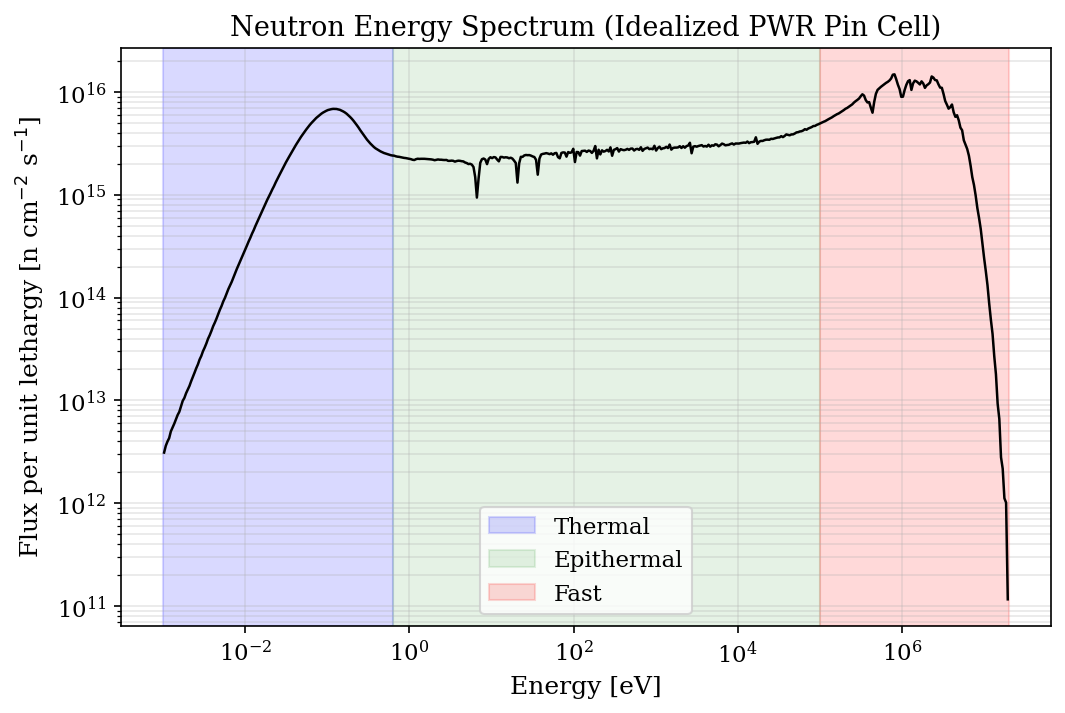

   Saved: 07_thermal_fast_maps.png  |  07_thermal_fast_maps.pdf


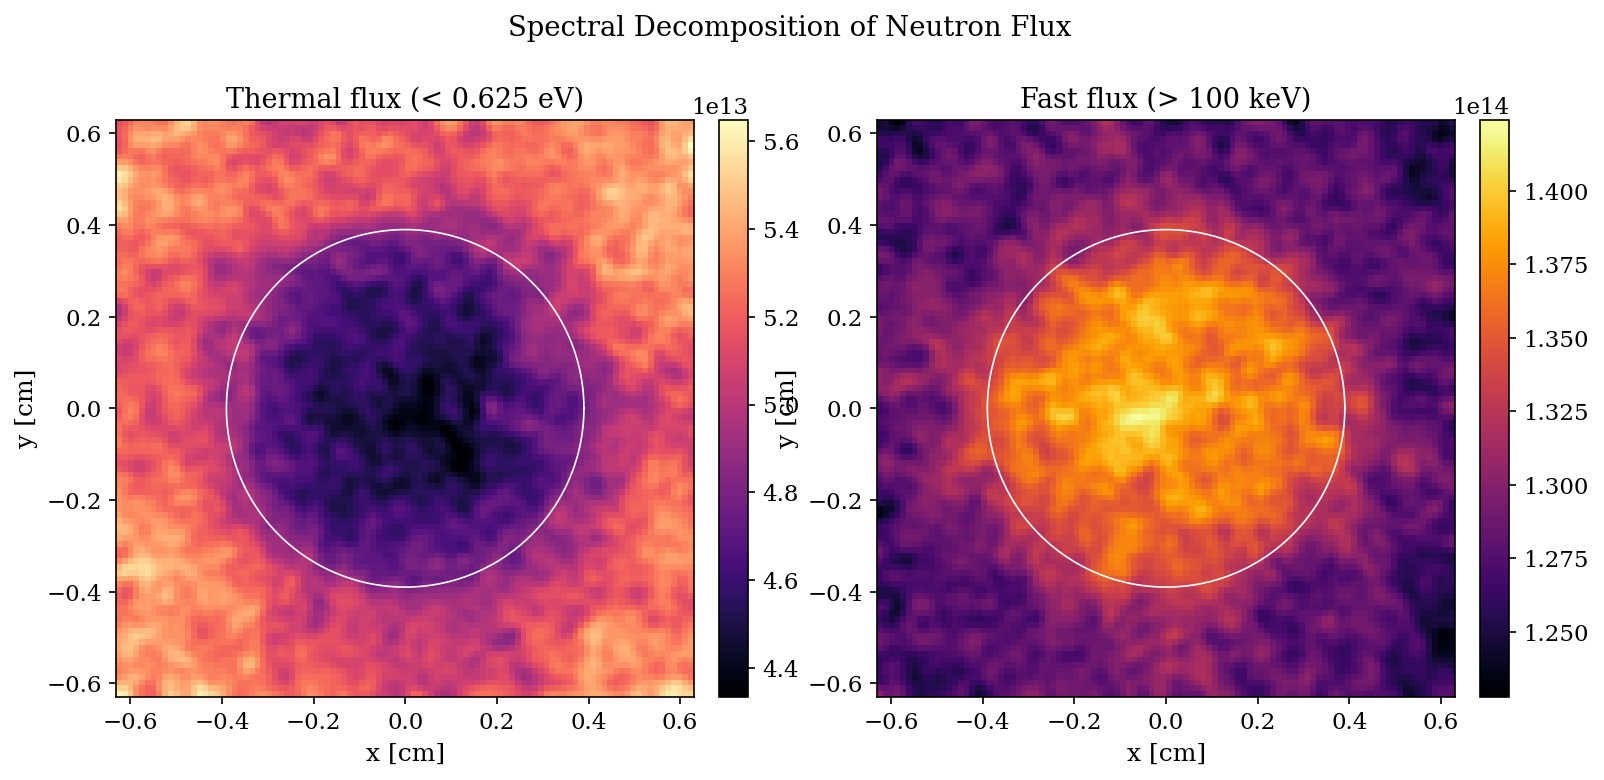

   Saved: 08_spectral_index.png  |  08_spectral_index.pdf


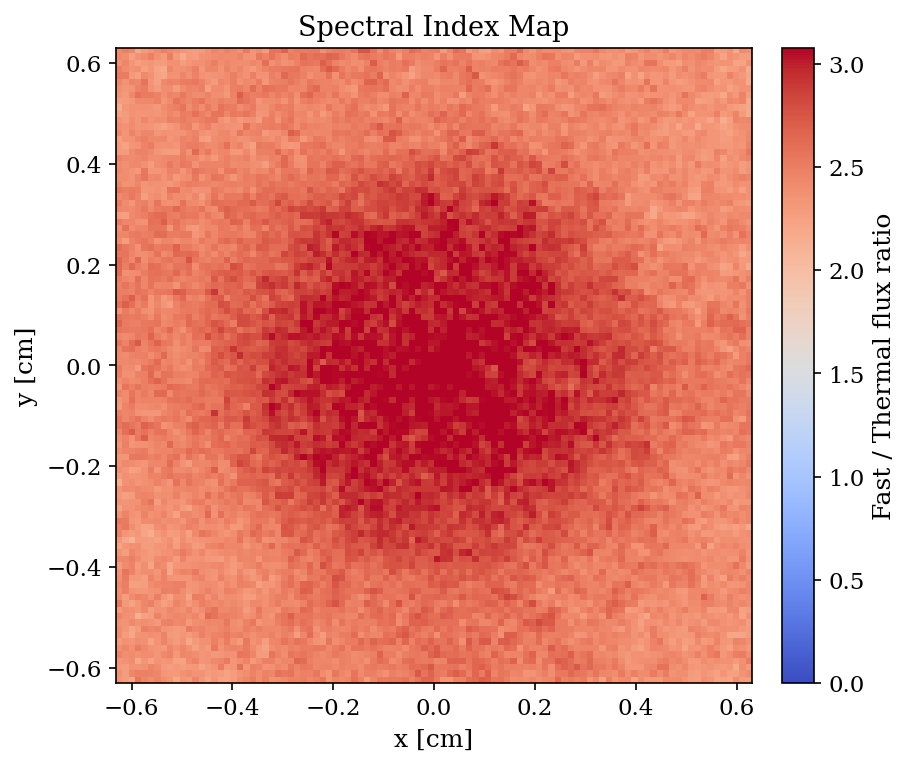

In [9]:
# ============================================================
# 8. ENERGY SPECTRUM + THERMAL / FAST MAPS
# ============================================================
sp = load_statepoint()

# The spectrum tally is integrated over the pin-cell volume. Convert
# from track length per source particle to physical flux, then to
# flux per unit natural lethargy d(ln E).
t_spec = sp.get_tally(name="flux_spectrum")
spec_raw = t_spec.mean.flatten()
spec_physical = spec_raw / PIN_CELL_VOLUME * source_rate
energy_lo = energy_bins[:-1]
energy_hi = energy_bins[1:]
d_lethargy = np.log(energy_hi / energy_lo)
flux_lethargy = spec_physical / d_lethargy
energy_mid = np.sqrt(energy_lo * energy_hi)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(energy_mid, flux_lethargy, "k-", lw=1.2)
ax.axvspan(1e-3, 0.625, alpha=0.15, color="blue", label="Thermal")
ax.axvspan(0.625, 1e5, alpha=0.10, color="green", label="Epithermal")
ax.axvspan(1e5, 2e7, alpha=0.15, color="red", label="Fast")
ax.set_xlabel("Energy [eV]")
ax.set_ylabel(r"Flux per unit lethargy [n cm$^{-2}$ s$^{-1}$]")
ax.set_title("Neutron Energy Spectrum (Idealized PWR Pin Cell)")
ax.legend(loc="lower center")
ax.grid(True, which="both", alpha=0.3)
save_fig("06_neutron_spectrum")
plt.show()

# Energy-filtered mesh tallies: convert to physical flux using the same
# source-rate and voxel-volume normalization.
th_raw = sp.get_tally(name="thermal_flux").get_values(scores=["flux"]).reshape(100, 100)
fa_raw = sp.get_tally(name="fast_flux").get_values(scores=["flux"]).reshape(100, 100)
th = th_raw / VOXEL_VOLUME * source_rate
fa = fa_raw / VOXEL_VOLUME * source_rate

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, title, cmap in zip(
    axes,
    [gaussian_filter(th, 1.0), gaussian_filter(fa, 1.0)],
    ["Thermal flux (< 0.625 eV)", "Fast flux (> 100 keV)"],
    ["magma", "inferno"],
):
    im = ax.imshow(data, origin="lower", extent=extent, cmap=cmap)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.plot(R_FUEL*np.cos(theta), R_FUEL*np.sin(theta), "w-", lw=0.8)
    ax.set_title(title)
    ax.set_xlabel("x [cm]")
    ax.set_ylabel("y [cm]")
plt.suptitle("Spectral Decomposition of Neutron Flux", y=1.02)
save_fig("07_thermal_fast_maps")
plt.show()

spectral_index = np.divide(fa, th, out=np.zeros_like(fa), where=th > 0)
positive_index = spectral_index[spectral_index > 0]
vmax_index = np.percentile(positive_index, 95) if positive_index.size else 1.0
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(spectral_index, origin="lower", extent=extent, cmap="coolwarm",
               vmin=0, vmax=max(vmax_index, 1e-12))
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Fast / Thermal flux ratio")
ax.set_title("Spectral Index Map")
ax.set_xlabel("x [cm]")
ax.set_ylabel("y [cm]")
save_fig("08_spectral_index")
plt.show()


## 9. Depletion / Burnup Analysis

A short depletion sequence is performed with the Predictor integrator at a **constant total thermal-power normalization of 175 W** for the 1 cm axial model. Because the modeled axial height is 1 cm, this corresponds to **175 W cm$^{-1}$ linear power**. The OpenMC depletion operator uses this power as the normalization of the depletion calculation.

The early depletion steps are intentionally smaller to resolve the initial transients. We track:

* $k_{\mathrm{eff}}$ evolution versus accumulated burnup
* $^{235}$U consumption
* $^{239}$Pu production
* $^{135}$Xe poisoning

The reported burnup is calculated from the specified constant power and the initial uranium heavy-metal mass of the 1 cm fuel segment.


Chain: /kaggle/input/datasets/afridijubairuthso/endfb71/chain_endfb71_pwr.xml
XS:    /kaggle/working/endfb-vii.1-hdf5/cross_sections.xml
--- CoupledOperator ---
Depletion normalization: constant total power = 175.0 W
Equivalent linear power = 175.0 W/cm for 1.0 cm
Initial U heavy-metal mass = 4.3383 g
--- integrate ---
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################

 Reading Mg24 from /kaggle/working/endfb-vii.1-hdf5/neutron/Mg24.h5
 Reading Mg25 from /kaggle/working/endfb-vii.1-hdf5/neutron/Mg25.h5
 Reading Mg26 from /kaggle/working/endfb-vii.1-hdf5/neutron/Mg26.h5
 Reading Al27 from /kaggle/working/endfb-vii.1-hdf5/neutron/Al27.h5
 Reading Si28 from /kaggle/working/endfb-vii.1-hdf5/neutron/Si28.h5
 Reading Si29 from /kaggle/working/endfb-vii.1-hdf5/neutron/Si29.h5
 Reading Si30 from /kaggle/working/endfb-vii.1-hdf5/neutron/Si30.h5
 Reading P31 from /kaggle/working/endfb-vii.1-hdf5/neutron/P31.h5
 Reading S32 from /kaggle/working/endfb-vii.1-hdf5/neutron/S32.h5
 Reading S33 from /kaggle/working/endfb-vii.1-hdf5/neutron/S33.h5
 Reading S34 from /kaggle/working/endfb-vii.1-hdf5/neutron/S34.h5
 Reading S36 from /kaggle/working/endfb-vii.1-hdf5/neutron/S36.h5
 Reading Cl35 from /kaggle/working/endfb-vii.1-hdf5/neutron/Cl35.h5
 Reading Cl37 from /kaggle/working/endfb-vii.1-hdf5/neutron/Cl37.h5
 Reading Ar36 from /kaggle/working/endfb-vii.1-hdf5/neutro

 Reading K40 from /kaggle/working/endfb-vii.1-hdf5/neutron/K40.h5
 Reading K41 from /kaggle/working/endfb-vii.1-hdf5/neutron/K41.h5
 Reading Ca40 from /kaggle/working/endfb-vii.1-hdf5/neutron/Ca40.h5
 Reading Ca42 from /kaggle/working/endfb-vii.1-hdf5/neutron/Ca42.h5
 Reading Ca43 from /kaggle/working/endfb-vii.1-hdf5/neutron/Ca43.h5
 Reading Ca44 from /kaggle/working/endfb-vii.1-hdf5/neutron/Ca44.h5
 Reading Ca46 from /kaggle/working/endfb-vii.1-hdf5/neutron/Ca46.h5
 Reading Ca48 from /kaggle/working/endfb-vii.1-hdf5/neutron/Ca48.h5
 Reading Sc45 from /kaggle/working/endfb-vii.1-hdf5/neutron/Sc45.h5
 Reading Ti46 from /kaggle/working/endfb-vii.1-hdf5/neutron/Ti46.h5
 Reading Ti47 from /kaggle/working/endfb-vii.1-hdf5/neutron/Ti47.h5
 Reading Ti48 from /kaggle/working/endfb-vii.1-hdf5/neutron/Ti48.h5
 Reading Ti49 from /kaggle/working/endfb-vii.1-hdf5/neutron/Ti49.h5
 Reading Ti50 from /kaggle/working/endfb-vii.1-hdf5/neutron/Ti50.h5
 Reading V50 from /kaggle/working/endfb-vii.1-hdf5/n

 Reading Se80 from /kaggle/working/endfb-vii.1-hdf5/neutron/Se80.h5
 Reading Se82 from /kaggle/working/endfb-vii.1-hdf5/neutron/Se82.h5
 Reading Br79 from /kaggle/working/endfb-vii.1-hdf5/neutron/Br79.h5
 Reading Br81 from /kaggle/working/endfb-vii.1-hdf5/neutron/Br81.h5
 Reading Kr78 from /kaggle/working/endfb-vii.1-hdf5/neutron/Kr78.h5
 Reading Kr80 from /kaggle/working/endfb-vii.1-hdf5/neutron/Kr80.h5
 Reading Kr82 from /kaggle/working/endfb-vii.1-hdf5/neutron/Kr82.h5
 Reading Kr83 from /kaggle/working/endfb-vii.1-hdf5/neutron/Kr83.h5
 Reading Kr84 from /kaggle/working/endfb-vii.1-hdf5/neutron/Kr84.h5
 Reading Kr85 from /kaggle/working/endfb-vii.1-hdf5/neutron/Kr85.h5
 Reading Kr86 from /kaggle/working/endfb-vii.1-hdf5/neutron/Kr86.h5
 Reading Rb85 from /kaggle/working/endfb-vii.1-hdf5/neutron/Rb85.h5
 Reading Rb86 from /kaggle/working/endfb-vii.1-hdf5/neutron/Rb86.h5
 Reading Rb87 from /kaggle/working/endfb-vii.1-hdf5/neutron/Rb87.h5
 Reading Sr84 from /kaggle/working/endfb-vii.1-h

 Reading Mo92 from /kaggle/working/endfb-vii.1-hdf5/neutron/Mo92.h5
 Reading Mo94 from /kaggle/working/endfb-vii.1-hdf5/neutron/Mo94.h5
 Reading Mo95 from /kaggle/working/endfb-vii.1-hdf5/neutron/Mo95.h5
 Reading Mo96 from /kaggle/working/endfb-vii.1-hdf5/neutron/Mo96.h5
 Reading Mo97 from /kaggle/working/endfb-vii.1-hdf5/neutron/Mo97.h5
 Reading Mo98 from /kaggle/working/endfb-vii.1-hdf5/neutron/Mo98.h5
 Reading Mo99 from /kaggle/working/endfb-vii.1-hdf5/neutron/Mo99.h5
 Reading Mo100 from /kaggle/working/endfb-vii.1-hdf5/neutron/Mo100.h5


...

 Reading Cs137 from /kaggle/working/endfb-vii.1-hdf5/neutron/Cs137.h5
 Reading Ba130 from /kaggle/working/endfb-vii.1-hdf5/neutron/Ba130.h5
 Reading Ba132 from /kaggle/working/endfb-vii.1-hdf5/neutron/Ba132.h5
 Reading Ba133 from /kaggle/working/endfb-vii.1-hdf5/neutron/Ba133.h5
 Reading Ba134 from /kaggle/working/endfb-vii.1-hdf5/neutron/Ba134.h5
 Reading Ba135 from /kaggle/working/endfb-vii.1-hdf5/neutron/Ba135.h5
 Reading Ba136 from /kaggle/working/endfb-vii.1-hdf5/neutron/Ba136.h5
 Reading Ba137 from /kaggle/working/endfb-vii.1-hdf5/neutron/Ba137.h5
 Reading Ba138 from /kaggle/working/endfb-vii.1-hdf5/neutron/Ba138.h5
 Reading Ba140 from /kaggle/working/endfb-vii.1-hdf5/neutron/Ba140.h5
 Reading La138 from /kaggle/working/endfb-vii.1-hdf5/neutron/La138.h5
 Reading La139 from /kaggle/working/endfb-vii.1-hdf5/neutron/La139.h5
 Reading La140 from /kaggle/working/endfb-vii.1-hdf5/neutron/La140.h5
 Reading Ce136 from /kaggle/working/endfb-vii.1-hdf5/neutron/Ce136.h5
 Reading Ce138 from 

          1200K
          2500K


 Reading Gd152 from /kaggle/working/endfb-vii.1-hdf5/neutron/Gd152.h5
 Reading Gd153 from /kaggle/working/endfb-vii.1-hdf5/neutron/Gd153.h5
 Reading Gd154 from /kaggle/working/endfb-vii.1-hdf5/neutron/Gd154.h5
 Reading Gd155 from /kaggle/working/endfb-vii.1-hdf5/neutron/Gd155.h5
 Reading Gd156 from /kaggle/working/endfb-vii.1-hdf5/neutron/Gd156.h5
 Reading Gd157 from /kaggle/working/endfb-vii.1-hdf5/neutron/Gd157.h5
 Reading Gd158 from /kaggle/working/endfb-vii.1-hdf5/neutron/Gd158.h5
 Reading Gd160 from /kaggle/working/endfb-vii.1-hdf5/neutron/Gd160.h5
 Reading Tb159 from /kaggle/working/endfb-vii.1-hdf5/neutron/Tb159.h5
 Reading Tb160 from /kaggle/working/endfb-vii.1-hdf5/neutron/Tb160.h5
 Reading Dy156 from /kaggle/working/endfb-vii.1-hdf5/neutron/Dy156.h5
 Reading Dy158 from /kaggle/working/endfb-vii.1-hdf5/neutron/Dy158.h5
 Reading Dy160 from /kaggle/working/endfb-vii.1-hdf5/neutron/Dy160.h5
 Reading Dy161 from /kaggle/working/endfb-vii.1-hdf5/neutron/Dy161.h5
 Reading Dy162 from 

          1200K


 Reading Cf252 from /kaggle/working/endfb-vii.1-hdf5/neutron/Cf252.h5
 Reading Cf253 from /kaggle/working/endfb-vii.1-hdf5/neutron/Cf253.h5
 Reading Cf254 from /kaggle/working/endfb-vii.1-hdf5/neutron/Cf254.h5
 Reading Es251 from /kaggle/working/endfb-vii.1-hdf5/neutron/Es251.h5
 Reading Es252 from /kaggle/working/endfb-vii.1-hdf5/neutron/Es252.h5
 Reading Es253 from /kaggle/working/endfb-vii.1-hdf5/neutron/Es253.h5
 Reading Es254 from /kaggle/working/endfb-vii.1-hdf5/neutron/Es254.h5
 Reading Es254_m1 from /kaggle/working/endfb-vii.1-hdf5/neutron/Es254_m1.h5
 Reading Es255 from /kaggle/working/endfb-vii.1-hdf5/neutron/Es255.h5
 Reading Fm255 from /kaggle/working/endfb-vii.1-hdf5/neutron/Fm255.h5
 Maximum neutron transport energy: 20000000 eV for O17
 Initializing source particles...

 ====================>     K EIGENVALUE SIMULATION     <====================

  Bat./Gen.      k            Average k
  =========   ========   ====================
        1/1    1.35992
        2/1    1.

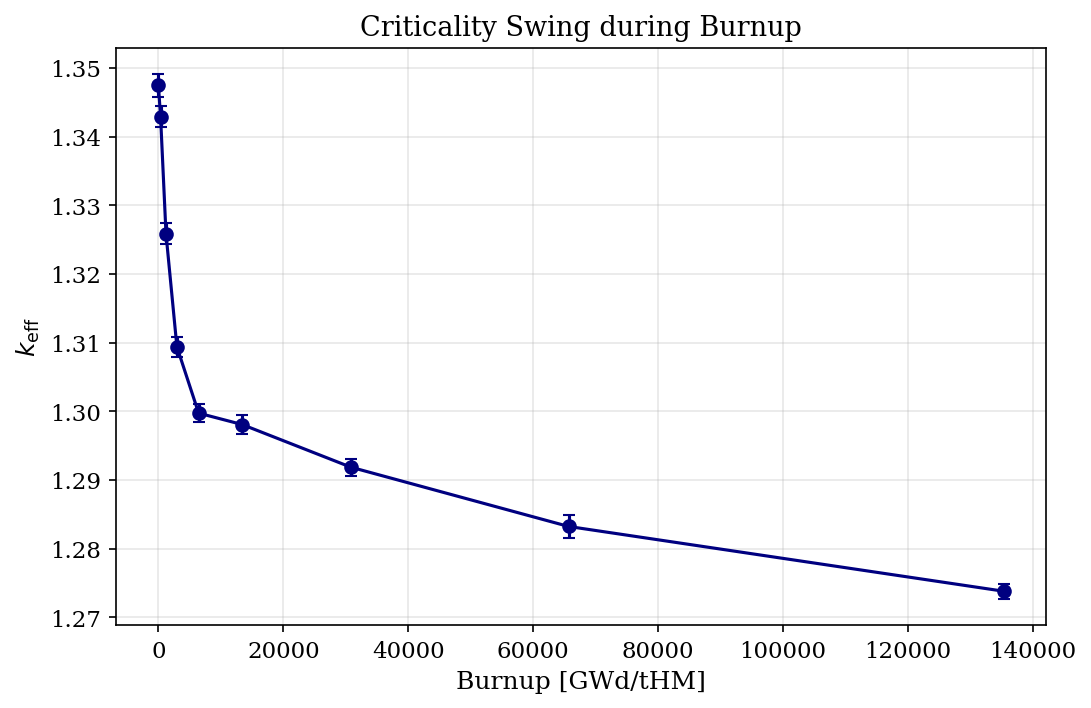

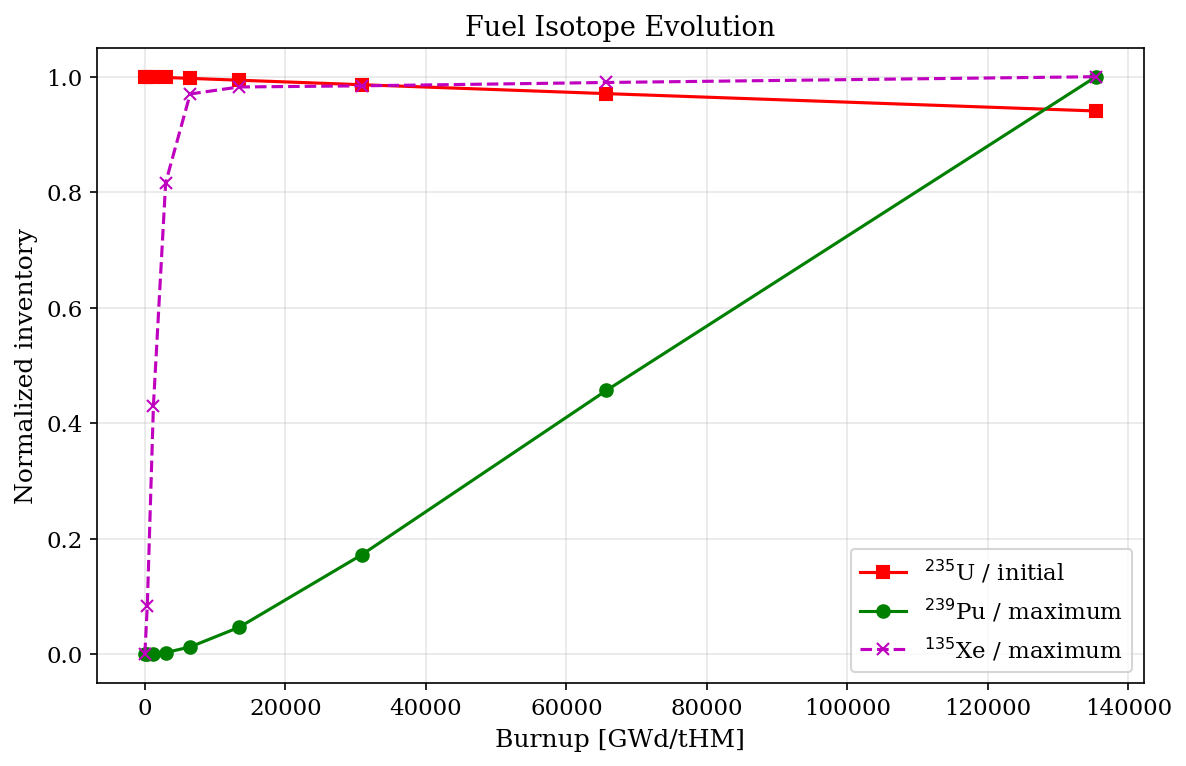

Final burnup = 135400.3913 GWd/tHM
Final k-eff = 1.27380 +/- 0.00111


In [10]:
# ============================================================
# 9. DEPLETION
# ============================================================
import os
import io
import contextlib
import numpy as np
import openmc
import openmc.deplete
import openmc.model
import matplotlib.pyplot as plt

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

for f in ["materials.xml", "geometry.xml", "settings.xml", "tallies.xml",
          "model.xml", "plots.xml", "summary.h5", "tallies.out",
          "depletion_results.h5"]:
    if os.path.exists(f):
        os.remove(f)

CHAIN = "/kaggle/input/datasets/afridijubairuthso/endfb71/chain_endfb71_pwr.xml"
XS = "/kaggle/working/endfb-vii.1-hdf5/cross_sections.xml"
assert os.path.exists(CHAIN), CHAIN
assert os.path.exists(XS), XS

os.environ["OPENMC_CROSS_SECTIONS"] = XS
openmc.config["cross_sections"] = XS
openmc.config["chain_file"] = CHAIN
print("Chain:", CHAIN)
print("XS:   ", XS)

fuel_d = openmc.Material(name="UO2 Fuel")
fuel_d.add_element("U", 1.0, enrichment=3.2)
fuel_d.add_element("O", 2.0)
fuel_d.set_density("g/cm3", 10.3)
fuel_d.temperature = 900.0
fuel_d.volume = float(np.pi * (0.39 ** 2) * 1.0)
fuel_d.depletable = True

clad_d = openmc.Material(name="Zircaloy")
clad_d.add_element("Zr", 1.0)
clad_d.set_density("g/cm3", 6.55)
clad_d.temperature = 600.0

water_d = openmc.Material(name="Light Water")
water_d.add_element("H", 2.0)
water_d.add_element("O", 1.0)
water_d.set_density("g/cm3", 0.7)
water_d.temperature = 600.0
water_d.add_s_alpha_beta("c_H_in_H2O")

fuel_or = openmc.ZCylinder(r=0.39)
clad_or = openmc.ZCylinder(r=0.45)
box = openmc.model.RectangularPrism(width=1.26, height=1.26, boundary_type="reflective")
geom_d = openmc.Geometry([
    openmc.Cell(fill=fuel_d,  region=-fuel_or),
    openmc.Cell(fill=clad_d,  region=+fuel_or & -clad_or),
    openmc.Cell(fill=water_d, region=+clad_or & -box),
])

settings_dep = openmc.Settings()
settings_dep.run_mode = "eigenvalue"
settings_dep.batches = 50
settings_dep.inactive = 15
settings_dep.particles = 12000
settings_dep.temperature = {"default": 600.0, "method": "nearest"}
settings_dep.source = openmc.IndependentSource(
    space=openmc.stats.Box([-0.3, -0.3, -0.5], [0.3, 0.3, 0.5])
)
settings_dep.output = {"tallies": False, "summary": False}

model_dep = openmc.Model(
    geometry=geom_d,
    materials=openmc.Materials([fuel_d, clad_d, water_d]),
    settings=settings_dep,
)

# ------------------------------------------------------------
# Explicit depletion normalization
# ------------------------------------------------------------
# PredictorIntegrator's power argument is the constant total thermal
# power used to normalize the depletion calculation.
TARGET_POWER_W = 175.0
AXIAL_HEIGHT_CM = 1.0
LINEAR_POWER_W_PER_CM = TARGET_POWER_W / AXIAL_HEIGHT_CM

# Initial uranium heavy-metal mass in the 1 cm fuel segment.
M_U235 = 235.0439299
M_U238 = 238.0507884
M_O16 = 15.999
U_ATOMIC_MASS = 0.032 * M_U235 + 0.968 * M_U238
U_MASS_FRACTION_IN_UO2 = U_ATOMIC_MASS / (U_ATOMIC_MASS + 2.0 * M_O16)
FUEL_VOLUME_CM3 = float(np.pi * 0.39**2 * AXIAL_HEIGHT_CM)
FUEL_MASS_G = 10.3 * FUEL_VOLUME_CM3
HM_MASS_KG = FUEL_MASS_G * U_MASS_FRACTION_IN_UO2 / 1000.0

print("--- CoupledOperator ---")
print(f"Depletion normalization: constant total power = {TARGET_POWER_W:.1f} W")
print(f"Equivalent linear power = {LINEAR_POWER_W_PER_CM:.1f} W/cm for {AXIAL_HEIGHT_CM:.1f} cm")
print(f"Initial U heavy-metal mass = {HM_MASS_KG*1000:.4f} g")

op = openmc.deplete.CoupledOperator(
    model_dep,
    chain_file=CHAIN,
)

timesteps = [0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0]  # days
integrator = openmc.deplete.PredictorIntegrator(
    op, timesteps, TARGET_POWER_W, timestep_units="d"
)

print("--- integrate ---")
with contextlib.redirect_stdout(io.StringIO()):
    integrator.integrate()
print("OK: depletion_results.h5")

results = openmc.deplete.Results("depletion_results.h5")
time, keff = results.get_keff()
days = np.asarray(time) / (24.0 * 3600.0)
burnup_gwd_tHM = days * TARGET_POWER_W * 86400.0 / (HM_MASS_KG * 1.0e6)

os.makedirs("/kaggle/working/figures", exist_ok=True)

# 9a. k-effective versus accumulated burnup
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(burnup_gwd_tHM, keff[:, 0], yerr=keff[:, 1], fmt="-o", color="navy", capsize=3)
ax.set_xlabel(r"Burnup [GWd/tHM]")
ax.set_ylabel(r"$k_{\mathrm{eff}}$")
ax.set_title("Criticality Swing during Burnup")
ax.grid(True, alpha=0.3)
fig.savefig("/kaggle/working/figures/09_keff_burnup.png", dpi=600, bbox_inches="tight")
plt.show()

_, u235 = results.get_atoms(fuel_d, "U235")
_, pu239 = results.get_atoms(fuel_d, "Pu239")
_, xe135 = results.get_atoms(fuel_d, "Xe135")

# U-235 has a nonzero initial inventory, whereas fresh Pu-239 and Xe-135
# are essentially zero. Therefore, use initial-value normalization for
# U-235 and maximum-value normalization for the two species that build up.
u235_norm = u235 / max(abs(u235[0]), 1e-30)
pu239_norm = pu239 / max(np.max(np.abs(pu239)), 1e-30)
xe135_norm = xe135 / max(np.max(np.abs(xe135)), 1e-30)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(burnup_gwd_tHM, u235_norm, "r-s", label=r"$^{235}$U / initial")
ax.plot(burnup_gwd_tHM, pu239_norm, "g-o", label=r"$^{239}$Pu / maximum")
ax.plot(burnup_gwd_tHM, xe135_norm, "m--x", label=r"$^{135}$Xe / maximum")
ax.set_xlabel(r"Burnup [GWd/tHM]")
ax.set_ylabel("Normalized inventory")
ax.set_title("Fuel Isotope Evolution")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
fig.savefig("/kaggle/working/figures/10_isotope_evolution.png", dpi=600, bbox_inches="tight")
plt.show()

print(f"Final burnup = {burnup_gwd_tHM[-1]:.4f} GWd/tHM")
print(f"Final k-eff = {keff[-1, 0]:.5f} +/- {keff[-1, 1]:.5f}")


## 10. Summary of Key Results & Research Outlook

| Quantity | Value / Observation |
|----------|---------------------|
| Geometry | Idealized unborated infinite PWR pin cell, 3.2 % UO$_2$, Zircaloy, H$_2$O + $S(\alpha,\beta)$ |
| $k_{\mathrm{eff}}$ (fresh) | Reported above with statistical uncertainty |
| Flux / power maps | Physically normalized using a 175 W total-power reference for the 1 cm axial model |
| Spectral index | Fast / thermal flux ratio with strong spatial variation |
| Burnup behaviour | $^{235}$U depletion, $^{239}$Pu and $^{135}$Xe evolution, and declining $k_{\mathrm{eff}}$ |

### Possible extensions 

1. **Multi-assembly / full-core models** with domain decomposition or random-ray acceleration
2. **Temperature feedback** (Doppler + moderator density) coupled to a simple thermal-hydraulics solver
3. **Sensitivity / uncertainty quantification** with OpenMC perturbation or Whisper-style methodologies
4. **Reduced-order modelling** of the depletion trajectories for real-time core follow
5. **Nuclear-data adjustment** using the pin-cell as a benchmark against measured reaction rates


In [11]:
# ============================================================
# 10. FINAL CHECKLIST
# ============================================================
import pathlib

fig_dir = pathlib.Path("/kaggle/working/figures")
work = pathlib.Path("/kaggle/working")

print("\n" + "=" * 60)
print("FIGURES SAVED IN /kaggle/working/figures/")
print("=" * 60)
if fig_dir.exists():
    files = sorted(fig_dir.glob("*"))
    if files:
        for f in files:
            print(f"  - {f.name}")
    else:
        print("  (folder empty — re-run plotting cells if needed)")
else:
    print("  (figures folder not found yet)")

print("\nStatePoint / depletion files:")
h5s = sorted(work.glob("*.h5"))
if h5s:
    for f in h5s:
        print(f"  - {f.name}")
else:
    print("  (none found in /kaggle/working)")

print("\nNeutronics workflow complete.")


FIGURES SAVED IN /kaggle/working/figures/
  - 02_flux_map.pdf
  - 02_flux_map.png
  - 03_flux_rel_error.pdf
  - 03_flux_rel_error.png
  - 04_power_density.pdf
  - 04_power_density.png
  - 05_radial_flux_profile.pdf
  - 05_radial_flux_profile.png
  - 06_neutron_spectrum.pdf
  - 06_neutron_spectrum.png
  - 07_thermal_fast_maps.pdf
  - 07_thermal_fast_maps.png
  - 08_spectral_index.pdf
  - 08_spectral_index.png
  - 09_keff_burnup.png
  - 10_isotope_evolution.png

StatePoint / depletion files:
  - depletion_results.h5
  - openmc_simulation_n0.h5
  - openmc_simulation_n1.h5
  - openmc_simulation_n2.h5
  - openmc_simulation_n3.h5
  - openmc_simulation_n4.h5
  - openmc_simulation_n5.h5
  - openmc_simulation_n6.h5
  - openmc_simulation_n7.h5
  - openmc_simulation_n8.h5
  - statepoint.200.h5
  - statepoint.50.h5

Neutronics workflow complete.
